# Imports and setup

In [1]:
import sys
sys.path.append('..')


In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import h5py
import torch
from pathlib import Path

from realtime_sim.ctc_decoder import greedy_decode_batch

In [3]:
sns.set_theme(font='Arial', font_scale=1.2, style='white', palette=px.colors.qualitative.Plotly)
sns.set_style(rc={
    'axes.linewidth': 0.5,
    'xtick.bottom': True,
    'ytick.left': True,
    'svg.fonttype': 'none'
    })

# Data loading and params

In [4]:
pt_names = ['S14', 'S22', 'S23', 'S26', 'S33', 'S39', 'S58', 'S62']
DATA_DIR = Path('../data/')
zscore=True
tw_select = [0.25, 4]
tw_orig = [0, 4]
paper_pt_dict = {'S14': 'S1', 'S26': 'S2', 'S33': 'S3', 'S22': 'S4', 'S23': 'S5', 'S39': 'S6', 'S58': 'S7', 'S62': 'S8'}

In [5]:
PHON_DICT = {
    0: 'blank',
    1: 'a',
    2: 'ae',
    3: 'i',
    4: 'u',
    5: 'b',
    6: 'p',
    7: 'v',
    8: 'g',
    9: 'k',
}

In [6]:
def load_data(data_filename, pt, tw_select, tw_orig, zscore=False, only_train=False):
    feat_key_train = 'norm_rt_HG_pow_z' if zscore else 'norm_rt_HG_pow'
    feat_key_test = 'norm_rt_HG_test_pow_z' if zscore else 'norm_rt_HG_test_pow'

    # load data
    with h5py.File(data_filename, 'r') as f:
        feats_train = f[f'{pt}/{feat_key_train}'][:].transpose(0, 2, 1)  # reshape to (n_trials, n_time, n_channels)
        labels_train = f[f'{pt}/labels_train'][:]
        if only_train:
            feats_test = None
            labels_test = None
        else:
            feats_test = f[f'{pt}/{feat_key_test}'][:].transpose(0, 2, 1)
            labels_test = f[f'{pt}/labels_test'][:]

    # select desired time window
    t_range_orig = np.linspace(tw_orig[0], tw_orig[1], feats_train.shape[1])
    t_select_mask = (t_range_orig >= tw_select[0]) & (t_range_orig <= tw_select[1])
    feats_train = feats_train[:, t_select_mask, :]
    if not only_train:
        feats_test = feats_test[:, t_select_mask, :]
    
    return feats_train, labels_train, feats_test, labels_test

In [7]:
pt_rt_data = {}
for pt in pt_names:
    feats_train, labels_train, _, _ = load_data(DATA_DIR / 'ctc_data' / 'ctc_data_stim_impute.h5', pt, tw_select, tw_orig, zscore=zscore, only_train=True)
    pt_rt_data[pt] = feats_train

In [8]:
FIG_DIR = Path('~/Box/Coganlab/Papers/2025/cross-patient-speech-decoding/figures/fig_5').expanduser()
ctc_res_dir = DATA_DIR / 'results' / 'decoding' / 'ctc_results_90varNoDel_computeAlign_augs'

# Panel a

In [9]:
def plotly_to_mpl(palette):
    mpl_colors = []
    for c in palette:
        if c.startswith("rgb"):
            # Extract numbers from 'rgb(r,g,b)'
            r, g, b = map(int, c[4:-1].split(","))
            mpl_colors.append((r/255, g/255, b/255))
        else:
            mpl_colors.append(c)  # already hex
    return mpl_colors

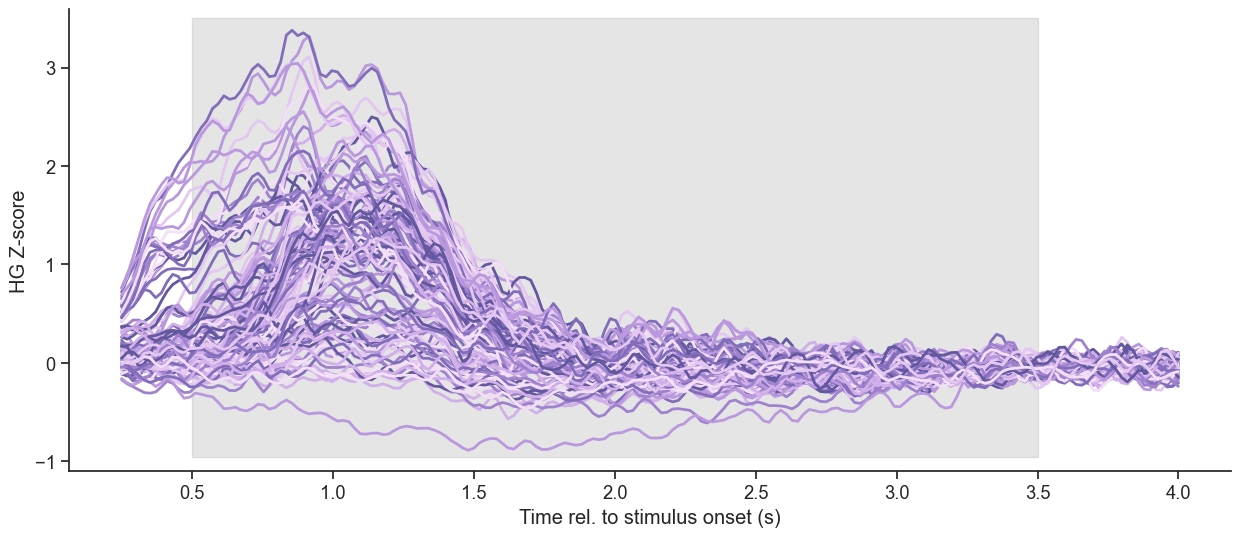

In [10]:
plotly_pal = px.colors.sequential.Purp
mpl_pal = plotly_to_mpl(plotly_pal)
sns.set_theme(font='Arial', font_scale=1.2, style='white', palette=mpl_pal)
sns.set_style(rc={
    'axes.linewidth': 0.5,
    'xtick.bottom': True,
    'ytick.left': True,
    })

plt.figure(figsize=(15,6))
chan_data = np.mean(pt_rt_data['S14'], axis=0)
plt.plot(np.linspace(tw_select[0], tw_select[1], feats_train.shape[1]), chan_data, alpha=1, linewidth=2)
plt.axvspan(xmin=0.5, xmax=3.5, ymin=0.03, ymax=0.98, color='grey', alpha=0.2)
plt.xlabel('Time rel. to stimulus onset (s)')
plt.ylabel('HG Z-score')
sns.despine()

plt.show()

In [18]:
cols = [i+1 for i in range(chan_data.shape[-1])]
chan_data_df = pd.DataFrame(chan_data, columns=cols)
chan_data_df['Time rel. to stimulus onset (s)'] = np.linspace(tw_select[0], tw_select[1], feats_train.shape[1])
chan_data_df = chan_data_df[['Time rel. to stimulus onset (s)'] + cols]
chan_data_df.to_csv(FIG_DIR / 'chanData_S1.csv')
chan_data_df

,Time rel. to stimulus onset (s),1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,128
0,0.250000,0.167228,0.049022,0.124254,-0.033983,0.129402,-0.040050,0.026828,0.167228,0.065489,...,0.174535,0.515957,0.106365,0.041504,0.692571,-0.009077,0.019900,0.044395,0.010068,-0.013646
1,0.270161,0.175429,-0.008648,0.125995,-0.082509,0.127666,-0.118263,0.005309,0.175429,0.098052,...,0.160923,0.619759,0.048597,0.026478,0.766908,-0.038142,-0.021667,0.105174,-0.000700,0.015703
2,0.290323,0.185213,-0.031221,0.090672,-0.068604,0.105558,-0.155570,-0.001581,0.185213,0.089945,...,0.066581,0.751325,0.054930,0.020957,0.837985,-0.039719,-0.075810,0.107602,0.004539,-0.004076
3,0.310484,0.214037,0.051433,0.050831,0.019577,0.085216,-0.141136,0.032784,0.214037,0.111415,...,-0.034125,0.915782,0.102503,0.031907,0.999991,-0.054065,-0.066874,0.062473,0.033107,0.019945
4,0.330645,0.252109,0.155798,0.019358,0.068802,0.116754,-0.067915,0.092991,0.252109,0.131052,...,-0.013523,1.107437,0.150620,0.062273,1.205468,-0.047423,-0.027187,0.043739,0.061414,0.098099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,3.919355,-0.061624,-0.270515,0.004234,-0.004064,-0.093892,-0.111765,0.003871,-0.061624,-0.075499,...,-0.006432,0.017064,-0.062499,-0.049717,-0.018200,-0.245912,0.003841,0.047980,-0.150283,0.001685
183,3.939516,-0.061458,-0.278184,-0.041665,0.057104,-0.069580,-0.111371,-0.041575,-0.061458,-0.068830,...,0.031213,0.102003,-0.108059,0.011047,-0.015285,-0.167751,-0.037836,0.096018,-0.158206,0.110877
184,3.959677,-0.047641,-0.195352,-0.054155,0.047780,-0.034723,-0.078768,-0.073557,-0.047641,-0.058689,...,-0.010333,0.125805,-0.084296,-0.008854,0.035244,-0.099400,-0.082582,0.078103,-0.135515,0.135059
185,3.979839,-0.036695,-0.116536,-0.070241,0.021352,-0.001796,-0.041086,-0.093410,-0.036695,-0.074594,...,-0.067594,0.048356,-0.017560,-0.047368,0.041484,-0.061463,-0.076825,0.040948,-0.103186,0.048119


In [12]:
# get logits
pt = 'S1'
logits = np.load(FIG_DIR / f'{pt}_logits.npy')
preds = greedy_decode_batch(torch.tensor(logits))
pred_seqs = [[PHON_DICT[int(p)] for p in pred] for pred in preds]
true_seqs = np.load(FIG_DIR / f'{pt}_true_seqs.npy')
t_logits = np.linspace(0.5, 3.5, logits.shape[1])
phon_colors =['C1', 'C2', 'C3', 'C4', 'C5', 'C6']

In [13]:
t_logits_select = np.where((t_logits > 1) & (t_logits < 2.5))[0]
logits_select = logits[:, t_logits_select]
t_logits = t_logits[t_logits_select]

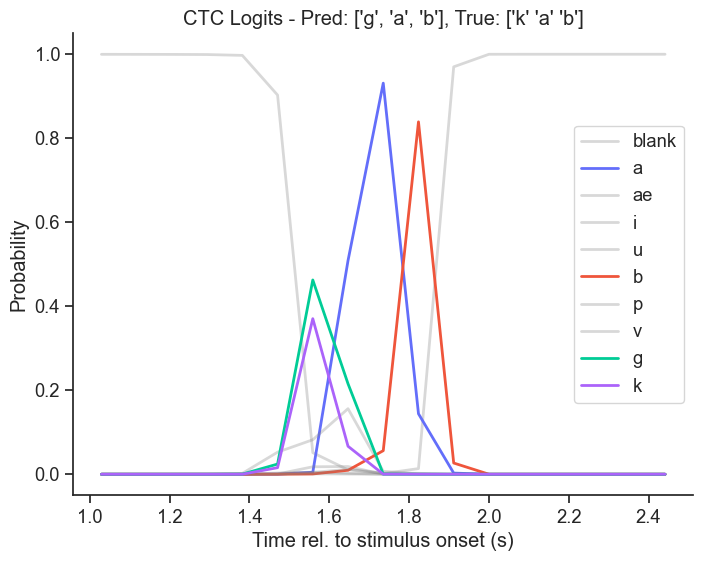

In [14]:
sns.set_theme(font='Arial', font_scale=1.2, style='white', palette=px.colors.qualitative.Plotly)
sns.set_style(rc={
    'axes.linewidth': 0.5,
    'xtick.bottom': True,
    'ytick.left': True,
    })

tr_vis = 34

i_color = 0
plt.figure(figsize=(8,6))
for k_phon, v_phon in PHON_DICT.items():
    if v_phon in pred_seqs[tr_vis] or v_phon in true_seqs[tr_vis]:
        plt.plot(t_logits, np.exp(logits_select[tr_vis,:,k_phon]), alpha=1, linewidth=2, label=v_phon)
    else:
        plt.plot(t_logits, np.exp(logits_select[tr_vis,:,k_phon]), alpha=0.3, linewidth=2, color='grey', label=v_phon)


plt.xlabel('Time rel. to stimulus onset (s)')
plt.ylabel('Probability')
plt.title(f'CTC Logits - Pred: {pred_seqs[tr_vis]}, True: {true_seqs[tr_vis]}')
plt.legend()
sns.despine()

plt.savefig(FIG_DIR / f'S1_tr{tr_vis+1}_ctcLogits_zoomIn.svg', format='svg')
plt.show()

In [19]:
logit_data = np.empty((len(t_logits), len(PHON_DICT))) * np.nan
for j in PHON_DICT.keys():
    logit_data[:,j] = np.exp(logits_select[tr_vis,:,j])

logit_df = pd.DataFrame(logit_data, columns=[v for _,v in PHON_DICT.items()])
logit_df['Time rel. to stimulus onset (s)'] = t_logits
logit_df = logit_df[['Time rel. to stimulus onset (s)'] + [v for _,v in PHON_DICT.items()]]
logit_df.to_csv(FIG_DIR / 'logits_S1_tr34.csv')
logit_df

,Time rel. to stimulus onset (s),blank,a,ae,i,u,b,p,v,g,k
0,1.029412,0.999806,1.031637e-06,5.574315e-07,3.379154e-06,0.000166,7.618909e-07,3.962109e-06,9.106977e-07,1.470996e-05,2.297017e-06
1,1.117647,0.999738,9.224474e-07,6.725024e-07,5.349299e-06,0.000222,6.746955e-07,4.423261e-06,1.218613e-06,2.360334e-05,3.228775e-06
2,1.205882,0.999608,9.348308e-07,9.105779e-07,9.141213e-06,0.000327,6.618079e-07,5.373653e-06,1.761480e-06,4.085244e-05,5.448675e-06
3,1.294118,0.999279,1.292495e-06,1.566229e-06,1.940495e-05,0.000591,8.302490e-07,8.001231e-06,3.094511e-06,8.148469e-05,1.426349e-05
4,1.382353,0.997286,4.082468e-06,6.493563e-06,8.425349e-05,0.002123,2.169136e-06,2.064805e-05,1.081515e-05,3.563457e-04,1.043175e-04
5,1.470588,0.902829,1.962887e-04,6.126899e-04,2.960329e-03,0.052546,6.563565e-05,3.883847e-04,4.489834e-04,2.425742e-02,1.562943e-02
6,1.558824,0.051356,4.710487e-03,1.778755e-02,4.885621e-03,0.082152,7.151633e-04,9.487884e-04,4.334592e-03,4.625633e-01,3.704005e-01
7,1.647059,0.010587,5.087768e-01,1.837131e-02,2.288977e-03,0.156120,9.468612e-03,4.494606e-04,1.174912e-02,2.154583e-01,6.665861e-02
8,1.735294,0.001564,9.311686e-01,2.268869e-04,7.603144e-05,0.007096,5.615672e-02,3.755257e-05,2.915980e-03,4.829971e-04,2.718180e-04
9,1.823529,0.013483,1.440346e-01,6.365315e-05,5.764991e-05,0.000862,8.390493e-01,3.691393e-05,2.220609e-03,5.186892e-05,1.327987e-04


# Panel b

In [20]:
res_pts = ['S14', 'S26', 'S22', 'S23', 'S39', 'S58', 'S62']
contexts = {'Chance': '_chance', 'Patient-specific': '_ptSpecific', 'Unaligned': '_unaligned', 'Aligned': '_aligned'}
tw = [0.5, 3.5]

ctc_decode_df = pd.DataFrame()
for pt in res_pts:
    skip_outer = False

    pers = np.empty((len(contexts), 100)) * np.nan
    for i, (context, c_suffix) in enumerate(contexts.items()):
        res_path = ctc_res_dir / f'{pt}/{pt}_ctcRNN_decodeTW([{tw[0]},{tw[1]}]){c_suffix}.h5'
        try:
            with h5py.File(res_path, 'r') as f:
                pers_data = f['phoneme_error_rate'][:]
                pers[i, :len(pers_data)] = pers_data
        except FileNotFoundError:
            print(f'{str(res_path)} not found. Skipping patient {pt}.')
            skip_outer=True
            # break
    
    if skip_outer:
        continue
        
    pt_df = pd.DataFrame(pers.T, columns=list(contexts.keys()))
    pt_df = pt_df.dropna()
    pt_df = pt_df.melt(var_name='Decoding type', value_name='Phoneme error rate')
    pt_df['Patient'] = paper_pt_dict[pt]
    ctc_decode_df = pd.concat([ctc_decode_df, pt_df], axis=0)
ctc_decode_df.reset_index(drop=True, inplace=True)
ctc_decode_df

,Decoding type,Phoneme error rate,Patient
0,Chance,86.538462,S1
1,Chance,83.333333,S1
2,Chance,84.615385,S1
3,Chance,84.615385,S1
4,Chance,87.179487,S1
...,...,...,...
1395,Aligned,86.538462,S8
1396,Aligned,83.333333,S8
1397,Aligned,79.487179,S8
1398,Aligned,82.051282,S8


In [ ]:
mean_ctc_decode_df = ctc_decode_df.groupby(['Patient', 'Decoding type'], sort=False).mean().reset_index()

fig = px.line(mean_ctc_decode_df, x='Decoding type', y='Phoneme error rate', color='Patient', width=800, height=500)
fig.add_traces(px.box(mean_ctc_decode_df, x='Decoding type', y='Phoneme error rate').data)
fig.update_layout(
    plot_bgcolor='white',
    legend=dict(
        orientation='h',
        yanchor='top',
        y=1.03,
        xanchor='left',
        x=0.02,
        title_text=''
    ),
    title_text=f'CTC-RNN Decoding',
    title_x=0.5,
    font=dict(size=18, family='Arial')
)
fig.update_xaxes(
    title='',
    mirror=False,
    ticks='outside',
    showline=True,
    linecolor='black',
    showgrid=False,
)
fig.update_yaxes(
    title='Phoneme error rate (%)',
    mirror=False,
    ticks='outside',
    showline=True,
    linecolor='black',
    showgrid=False,
    range=[60, 100]
    # range=[20, 50]
)

fig.write_image(FIG_DIR / 'ctcRNN_fullDecoding.svg')
fig.show()

In [12]:
stat_chance_pers = mean_ctc_decode_df[mean_ctc_decode_df['Decoding type'] == 'Chance']['Phoneme error rate'].values
stat_ps_pers = mean_ctc_decode_df[mean_ctc_decode_df['Decoding type'] == 'Patient-specific']['Phoneme error rate'].values
stat_un_pers = mean_ctc_decode_df[mean_ctc_decode_df['Decoding type'] == 'Unaligned']['Phoneme error rate'].values
stat_cca_pers = mean_ctc_decode_df[mean_ctc_decode_df['Decoding type'] == 'Aligned']['Phoneme error rate'].values

pvals = []

res_chance_ps = stats.wilcoxon(stat_chance_pers, stat_ps_pers)
print(res_chance_ps)
pvals.append(res_chance_ps.pvalue)

res_ps_un = stats.wilcoxon(stat_ps_pers, stat_un_pers)
print(res_ps_un)
pvals.append(res_ps_un.pvalue)

res_ps_cca = stats.wilcoxon(stat_ps_pers, stat_cca_pers)
print(res_ps_cca)
pvals.append(res_ps_cca.pvalue)

res_un_cca = stats.wilcoxon(stat_un_pers, stat_cca_pers)
print(res_un_cca)
pvals.append(res_un_cca.pvalue)

pvals_corr = stats.false_discovery_control(pvals)
for p in pvals_corr:
    print(f'Corrected p-value: {p}')

WilcoxonResult(statistic=np.float64(12.0), pvalue=np.float64(0.8125))
WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.015625))
WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.015625))
WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.015625))
Corrected p-value: 0.8125
Corrected p-value: 0.020833333333333332
Corrected p-value: 0.020833333333333332
Corrected p-value: 0.020833333333333332


# Panel c

In [21]:
res_pts = ['S14', 'S26', 'S22', 'S23', 'S39', 'S58', 'S62']
contexts = {'Patient-specific': '_ptSpecific', 'Aligned': '_aligned'}
tss_list = np.arange(5, 101, 5)
tw = [0.5, 3.5]

tss_ctc_df = pd.DataFrame()
for pt in res_pts:
    skip_outer = False
    for r in tss_list:
        r_suffix = f'_tgtSubsamp{r}' if r != 100 else ''
        pers = np.empty((len(contexts), 100)) * np.nan
        for i, (context, c_suffix) in enumerate(contexts.items()):
            res_path = ctc_res_dir / f'{pt}/{pt}_ctcRNN_decodeTW([{tw[0]},{tw[1]}]){c_suffix}{r_suffix}.h5'
            try:
                with h5py.File(res_path, 'r') as f:
                    pers_data = f['phoneme_error_rate'][:]
                    pers[i, :len(pers_data)] = pers_data
            except FileNotFoundError:
                print(f'{str(res_path)} not found.')

    
        pt_df = pd.DataFrame(pers.T, columns=list(contexts.keys()))
        pt_df = pt_df.dropna()
        pt_df = pt_df.melt(var_name='Decoding type', value_name='Phoneme error rate')
        pt_df['Patient'] = paper_pt_dict[pt]
        pt_df['Subsampling ratio'] = r
        tss_ctc_df = pd.concat([tss_ctc_df, pt_df], axis=0)
tss_ctc_df.reset_index(drop=True, inplace=True)
tss_ctc_df

,Decoding type,Phoneme error rate,Patient,Subsampling ratio
0,Patient-specific,100.000000,S1,5
1,Patient-specific,92.948718,S1,5
2,Patient-specific,100.000000,S1,5
3,Patient-specific,99.358974,S1,5
4,Patient-specific,88.461538,S1,5
...,...,...,...,...
13995,Aligned,86.538462,S8,100
13996,Aligned,83.333333,S8,100
13997,Aligned,79.487179,S8,100
13998,Aligned,82.051282,S8,100


In [25]:
mean_tss_ctc_df = tss_ctc_df.groupby(['Subsampling ratio', 'Decoding type', 'Patient'], sort=False).mean().reset_index()
mean_tss_ctc_df = mean_tss_ctc_df.sort_values(by=['Subsampling ratio', 'Decoding type', 'Patient'])
mean_tss_ctc_df.to_csv(FIG_DIR / 'ctcRNN_tgtSubsamp.csv')
mean_tss_ctc_df

,Subsampling ratio,Decoding type,Patient,Phoneme error rate
1,5,Aligned,S1,84.782051
41,5,Aligned,S2,86.358974
81,5,Aligned,S4,86.423077
121,5,Aligned,S5,88.282051
161,5,Aligned,S6,87.487179
...,...,...,...,...
118,100,Patient-specific,S4,86.910256
158,100,Patient-specific,S5,91.153846
198,100,Patient-specific,S6,87.102564
238,100,Patient-specific,S7,92.306667


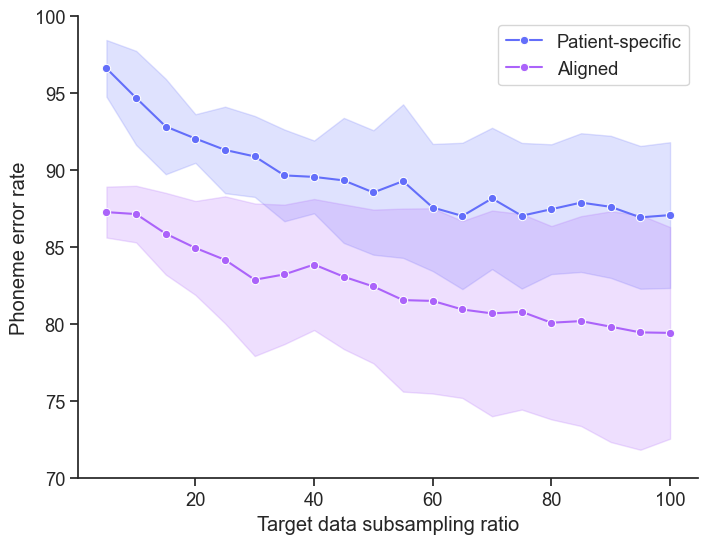

In [84]:
mean_tss_ctc_df = tss_ctc_df.groupby(['Subsampling ratio', 'Decoding type', 'Patient'], sort=False).mean().reset_index()

plt.subplots(1,1,figsize=(8,6))
sns.lineplot(data=mean_tss_ctc_df, x='Subsampling ratio', y='Phoneme error rate', hue='Decoding type', marker='o', errorbar='sd', palette=['#636EFA', '#AB63FA'])

plt.xlabel('Target data subsampling ratio')
plt.ylabel('Phoneme error rate')
plt.ylim(70, 100)
plt.legend()
sns.despine()

plt.savefig(FIG_DIR / 'ctcRNN_tgtSubsamp.svg', format='svg')
plt.show()

In [91]:
stat_vals = []
pvals = []
for ssr in mean_tss_ctc_df['Subsampling ratio'].unique():
    ps_per = mean_tss_ctc_df[(mean_tss_ctc_df['Subsampling ratio'] == ssr) & (mean_tss_ctc_df['Decoding type'] == 'Patient-specific')]['Phoneme error rate']
    align_per = mean_tss_ctc_df[(mean_tss_ctc_df['Subsampling ratio'] == ssr) & (mean_tss_ctc_df['Decoding type'] == 'Aligned')]['Phoneme error rate']
    res = stats.wilcoxon(ps_per, align_per)
    stat_vals.append(res.statistic)
    pvals.append(res.pvalue)

pvals_corr = stats.false_discovery_control(pvals)
for tss, pval, stat in zip(mean_tss_ctc_df['Subsampling ratio'].unique(), pvals_corr, stat_vals):
    print(f"TSS: {tss}, W: {stat}, p: {pval}")

TSS: 5, W: 0.0, p: 0.01644736842105263
TSS: 10, W: 0.0, p: 0.01644736842105263
TSS: 15, W: 0.0, p: 0.01644736842105263
TSS: 20, W: 0.0, p: 0.01644736842105263
TSS: 25, W: 0.0, p: 0.01644736842105263
TSS: 30, W: 0.0, p: 0.01644736842105263
TSS: 35, W: 0.0, p: 0.01644736842105263
TSS: 40, W: 0.0, p: 0.01644736842105263
TSS: 45, W: 0.0, p: 0.01644736842105263
TSS: 50, W: 0.0, p: 0.01644736842105263
TSS: 55, W: 0.0, p: 0.01644736842105263
TSS: 60, W: 1.0, p: 0.03125
TSS: 65, W: 0.0, p: 0.01644736842105263
TSS: 70, W: 0.0, p: 0.01644736842105263
TSS: 75, W: 0.0, p: 0.01644736842105263
TSS: 80, W: 0.0, p: 0.01644736842105263
TSS: 85, W: 0.0, p: 0.01644736842105263
TSS: 90, W: 0.0, p: 0.01644736842105263
TSS: 95, W: 0.0, p: 0.01644736842105263
TSS: 100, W: 0.0, p: 0.01644736842105263


# Panel d

In [26]:
res_pts = ['S14', 'S26', 'S22', 'S23',  'S39', 'S58', 'S62']
contexts = {'Aligned': '_aligned'}
tw = [0.5, 3.5]
avg_tr_duration = 3.75 / 60 # minutes

cps_ctc_df = pd.DataFrame()
for pt in res_pts:
    skip_outer = False
    pers = np.empty((len(contexts), 100)) * np.nan
    for i, (context, c_suffix) in enumerate(contexts.items()):
        tw = [0.5, 3.5] if pt in ['S58', 'S62'] else tw
        res_path = ctc_res_dir / f'{pt}/{pt}_ctcRNN_decodeTW([{tw[0]},{tw[1]}]){c_suffix}_crossPatientSubsamp.h5'
        try:
            with h5py.File(res_path, 'r') as f:
                for trial_str in [f for f in f.keys() if 'num_trials' in f]:
                    k_trials = int(trial_str.split('_')[-1])
                    pers_data = f[trial_str]['phoneme_error_rate'][:]
                    pers[i, :len(pers_data)] = pers_data

                    pt_df = pd.DataFrame(pers.T, columns=list(contexts.keys()))
                    pt_df = pt_df.dropna()
                    pt_df = pt_df.melt(var_name='Decoding type', value_name='Phoneme error rate')
                    pt_df['Patient'] = paper_pt_dict[pt]
                    pt_df['Cross-patient trials'] = k_trials
                    pt_df['Cross-patient data'] = k_trials * avg_tr_duration
                    cps_ctc_df = pd.concat([cps_ctc_df, pt_df], axis=0)
        except FileNotFoundError:
            print(f'{str(res_path)} not found.')
            skip_outer = True
            break
    if skip_outer:
        continue

cps_ctc_df.reset_index(drop=True, inplace=True)
cps_ctc_df

,Decoding type,Phoneme error rate,Patient,Cross-patient trials,Cross-patient data
0,Aligned,79.487179,S1,105,6.5625
1,Aligned,72.435897,S1,105,6.5625
2,Aligned,78.846154,S1,105,6.5625
3,Aligned,75.641026,S1,105,6.5625
4,Aligned,74.358974,S1,105,6.5625
...,...,...,...,...,...
5245,Aligned,85.897436,S8,921,57.5625
5246,Aligned,80.769231,S8,921,57.5625
5247,Aligned,77.564103,S8,921,57.5625
5248,Aligned,85.256410,S8,921,57.5625


In [28]:
mean_cps_df = cps_ctc_df.groupby(['Cross-patient trials', 'Decoding type', 'Patient']).mean().reset_index()
mean_cps_df.to_csv(FIG_DIR / 'ctcRNN_crossPtSubsamp.csv')
mean_cps_df

,Cross-patient trials,Decoding type,Patient,Phoneme error rate,Cross-patient data
0,35,Aligned,S1,75.256410,2.1875
1,35,Aligned,S2,73.333333,2.1875
2,35,Aligned,S4,91.666667,2.1875
3,35,Aligned,S5,87.038462,2.1875
4,35,Aligned,S6,90.256410,2.1875
...,...,...,...,...,...
100,921,Aligned,S4,83.564103,57.5625
101,921,Aligned,S5,83.333333,57.5625
102,921,Aligned,S6,83.076923,57.5625
103,921,Aligned,S7,85.680000,57.5625


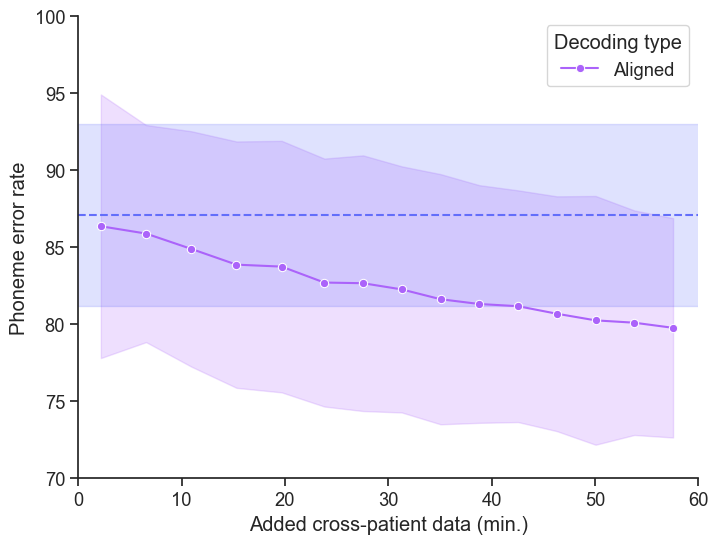

In [75]:
mean_cps_df = cps_ctc_df.groupby(['Cross-patient trials', 'Decoding type', 'Patient']).mean().reset_index()
plt.subplots(1,1,figsize=(8,6))

sns.lineplot(data=mean_cps_df, x='Cross-patient data', y='Phoneme error rate', hue='Decoding type', marker='o', errorbar='sd', palette=['#AB63FA'])

ps_mean = ctc_decode_df[ctc_decode_df['Decoding type'] == 'Patient-specific']['Phoneme error rate'].mean()
ps_std = ctc_decode_df[ctc_decode_df['Decoding type'] == 'Patient-specific']['Phoneme error rate'].std()
plt.axhline(ps_mean, color='#636EFA', linestyle='--')
plt.fill_between((-5,65), ps_mean - ps_std, ps_mean + ps_std, color='#636EFA', alpha=0.2)

plt.xlabel('Added cross-patient data (min.)')
plt.ylabel('Phoneme error rate')
plt.ylim([70,100])
plt.xlim([0,60])
sns.despine()

plt.savefig(FIG_DIR / 'ctcRNN_crossPtSubsamp.svg', format='svg')
plt.show()

In [92]:
ps_data = mean_ctc_decode_df[mean_ctc_decode_df['Decoding type'] == 'Patient-specific']['Phoneme error rate']

stat_vals = []
pvals = []
for data_time in mean_cps_df['Cross-patient data'].unique():
    align_data = mean_cps_df[mean_cps_df['Cross-patient data'] == data_time]['Phoneme error rate']

    res = stats.wilcoxon(ps_data[:len(align_data)], align_data)
    pvals.append(res.pvalue)
    stat_vals.append(res.statistic)

pvals_corr = stats.false_discovery_control(pvals)
for data_time, pval, stat in zip(mean_cps_df['Cross-patient data'].unique(), pvals_corr, stat_vals):
    print(f'Data amount: {data_time}, w: {stat}, p: {pval}')


Data amount: 2.1875, w: 14.0, p: 1.0
Data amount: 6.5625, w: 9.0, p: 0.5022321428571428
Data amount: 10.9375, w: 7.0, p: 0.34254807692307687
Data amount: 15.3125, w: 5.0, p: 0.1953125
Data amount: 19.6875, w: 4.0, p: 0.14914772727272727
Data amount: 23.8125, w: 3.0, p: 0.1171875
Data amount: 27.5625, w: 3.0, p: 0.1171875
Data amount: 31.3125, w: 1.0, p: 0.05859375
Data amount: 35.0625, w: 1.0, p: 0.05859375
Data amount: 38.8125, w: 0.0, p: 0.0390625
Data amount: 42.5625, w: 0.0, p: 0.0390625
Data amount: 46.3125, w: 0.0, p: 0.0390625
Data amount: 50.0625, w: 0.0, p: 0.0390625
Data amount: 53.8125, w: 0.0, p: 0.0390625
Data amount: 57.5625, w: 0.0, p: 0.0390625


In [77]:
lr_cps_df = mean_cps_df.drop(columns=['Decoding type', 'Patient']).groupby('Cross-patient data').mean()

log_x = mean_cps_df['Cross-patient data'].unique()
log_y = np.log(lr_cps_df['Phoneme error rate'].values)

log_res = stats.linregress(log_x, log_y)
print(f'LR on log transformed data: slope = {log_res.slope}, r2 = {log_res.rvalue**2}, p = {log_res.pvalue}')

log_x_proj = np.arange(0, 2000, 5)
log_y_proj = np.exp(log_res.intercept + log_res.slope * log_x_proj)

print(f'{log_x_proj[np.where(log_y_proj <= 25)[0][0]]} min. cross-patient data yield a PER of 25%')
print(f'{log_x_proj[np.where(log_y_proj <= 10)[0][0]]} min. cross-patient data yield a PER of 10%')

LR on log transformed data: slope = -0.0014203182437859377, r2 = 0.975928445758542, p = 6.621875221140612e-12
875 min. cross-patient data yield a PER of 25%
1520 min. cross-patient data yield a PER of 10%


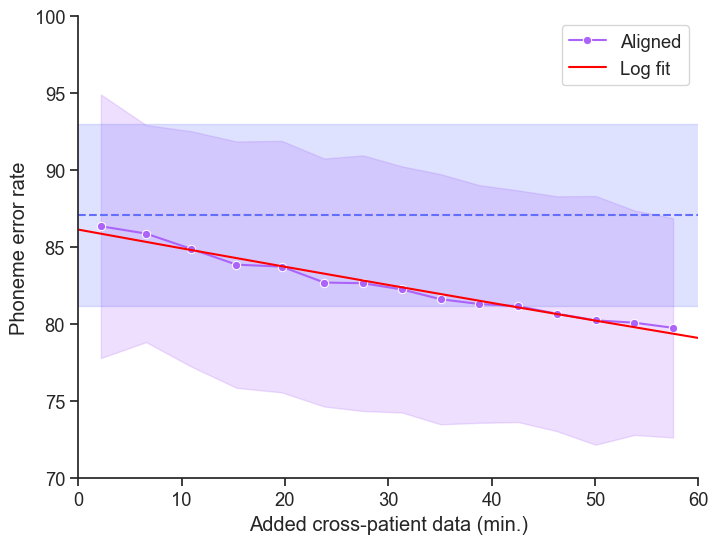

In [ ]:
plt.subplots(1,1,figsize=(8,6))

sns.lineplot(data=mean_cps_df, x='Cross-patient data', y='Phoneme error rate', hue='Decoding type', marker='o', errorbar='sd', palette=['#AB63FA'])

ps_mean = ctc_decode_df[ctc_decode_df['Decoding type'] == 'Patient-specific']['Phoneme error rate'].mean()
ps_std = ctc_decode_df[ctc_decode_df['Decoding type'] == 'Patient-specific']['Phoneme error rate'].std()
plt.axhline(ps_mean, color='#636EFA', linestyle='--')
plt.fill_between((-5,65), ps_mean - ps_std, ps_mean + ps_std, color='#636EFA', alpha=0.2)

# sns.lineplot(x=lr_x_proj, y=lr_y_proj, color='blue', label='Linear regression')
sns.lineplot(x=log_x_proj, y=log_y_proj, color='red', label='Log fit')

plt.xlabel('Added cross-patient data (min.)')
plt.ylabel('Phoneme error rate')
plt.ylim([70,100])
plt.xlim([0,60])
sns.despine()

plt.savefig(FIG_DIR / 'ctcRNN_crossPtSubsamp.svg', format='svg')
plt.show()

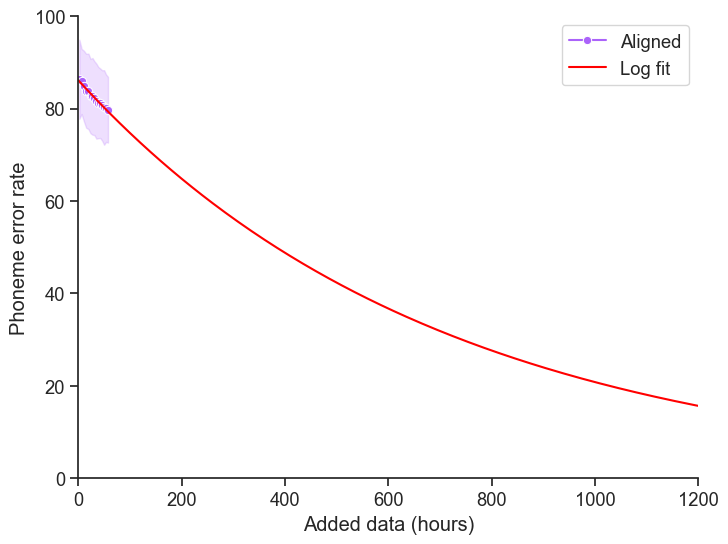

In [ ]:
plt.subplots(1,1,figsize=(8,6))

sns.lineplot(data=mean_cps_df, x='Cross-patient data', y='Phoneme error rate', hue='Decoding type', marker='o', errorbar='sd', palette=['#AB63FA'])

sns.lineplot(x=log_x_proj, y=log_y_proj, color='red', label='Log fit')

plt.xlabel('Added data (hours)')
plt.ylabel('Phoneme error rate')
plt.ylim([0,100])
plt.xlim([0,1200])
sns.despine()

plt.savefig(FIG_DIR / 'ctcRNN_crossPtSubsamp.svg', format='svg')
plt.show()